This notebook is based on the [Network Intrusion Detection - Binary Prediction](https://github.com/mohammedAcheddad/AI-Based-Network-IDS_ML-DL/blob/main/BinaryPrediction.ipynb) notebook from the [mohammedAcheddad/AI-Based-Network-IDS_ML-DL](https://github.com/mohammedAcheddad/AI-Based-Network-IDS_ML-DL) repository.

**🔐 Giới thiệu**

Demo hướng đến việc xây dựng **hệ thống phát hiện xâm nhập mạng (IDS)** hiện đại bằng **Machine Learning (ML)** và **Deep Learning (DL)**. Mục tiêu là phát hiện và phân loại các cuộc tấn công mạng một cách chính xác và nhanh chóng, vượt qua các hạn chế của IDS truyền thống.

**📂 Bộ dữ liệu sử dụng**

Dự án sử dụng bộ dữ liệu **NSL-KDD**: Cải tiến từ KDD’99, loại bỏ dữ liệu dư thừa và giúp đánh giá mô hình công bằng, không bị thiên lệch theo tần suất mẫu.

Đây là bộ dữ liệu cải tiến của KDD’99, KDD'99 hiện tại không còn phù hợp để sử dụng do có chứa nhiều dữ liệu trùng lặp gây lệch kết quả huấn luyện và không phù hợp với môi trường tấn công hiện đại.

Ngoài ra còn bộ dữ liệu UNSW-NB 15: Mô phỏng hoạt động mạng hiện đại với tấn công đa dạng, phản ánh thực tế tốt hơn, được tạo bởi công cụ IXIA và phân tích qua Argus & Bro-IDS.

**🧪 Xử lý dữ liệu**

Tiền xử lý dữ liệu:
- Loại bỏ đặc trưng không cần thiết
- Gom nhóm nhãn tấn công theo loại: DoS, Probe, R2L, U2R
- Mã hóa dữ liệu phân loại (One-Hot/Label Encoding)
- Chuẩn hóa giá trị số (Standard Scaling)
- Chia dữ liệu thành tập đặc trưng và nhãn mục tiêu

Phân loại đặc trưng:
- `Thông tin kết nối`: thời gian, giao thức, dịch vụ, trạng thái
- `Nội dung kết nối`: số lần đăng nhập sai, dữ liệu khẩn cấp, v.v.
- `Thông tin lưu lượng`: thống kê số kết nối, lỗi, tần suất truy cập
- `Nhãn (label)`: ‘Normal’ hoặc một trong 4 loại tấn công (DoS, Probe, R2L, U2R)

**✅ Machine Learning Models**
- Linear Regression, Gaussian Naive Bayes, Support Vector Machine (SVM), Decision Tree, Random Forest

🧠 Deep Learning Models:
- Convolutional Neural Network (CNN)

Các mô hình được đánh giá qua Accuracy, Precision, Recall, F1-score, chưa đánh giá AUC-ROC.

**Explainable AI**

SHAP (SHapley Additive exPlanations) là một phương pháp trong Explainable AI (XAI) dùng để giải thích dự đoán của mô hình máy học, bằng cách đo lường đóng góp của từng đặc trưng (feature) vào kết quả đầu ra của mô hình.

Ý tưởng chính của SHAP dựa trên lý thuyết Shapley values từ lý thuyết trò chơi:
- Mỗi đặc trưng (feature) được xem là một “người chơi” trong trò chơi dự đoán.
- Giá trị Shapley đo lường đóng góp công bằng của từng feature vào chênh lệch đầu ra của mô hình so với giá trị trung bình.

Ưu điểm của SHAP:
- Giải thích rõ ràng, định lượng: Cho biết mỗi feature ảnh hưởng như thế nào đến một dự đoán cụ thể.
- Tổng quát: Dùng được cho mọi loại mô hình (tree, linear, neural networks...).

Ví dụ trực quan: Một mô hình dự đoán xác suất bệnh tim là 70%.
- Tuổi cao	+0.15 (SHAP value)
- Huyết áp cao	+0.10
- Cholesterol thấp	-0.05

Các giá trị này cho thấy tuổi và huyết áp góp phần tăng khả năng mắc bệnh, còn cholesterol thấp giúp giảm rủi ro.

Tóm lại: SHAP là một phương pháp XAI mạnh mẽ, giúp hiểu rõ vì sao mô hình đưa ra quyết định, với nền tảng vững chắc từ lý thuyết trò chơi, hỗ trợ đánh giá công bằng và minh bạch trong mô hình AI.

## Importing necessary libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Scikit-learn: preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

# Scikit-learn: model selection & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics

# Scikit-learn: models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn import svm

# Scikit-learn: dimensionality reduction
from sklearn.decomposition import PCA

# XGBoost
import xgboost as xgb

# System
import warnings

# Settings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

# Only in Jupyter notebooks
%matplotlib inline

2025-04-18 14:39:32.187209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744987172.396989      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744987172.462321      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Exploring the dataset

In [2]:
# # Đường dẫn tới thư mục chứa dữ liệu trên Google Drive
data_path = '/kaggle/input/nslkdd/'

# Đọc tập tin huấn luyện "KDDTrain+.txt" của bộ dữ liệu NSL-KDD thành DataFrame
# Đây là dữ liệu được sử dụng để huấn luyện mô hình phát hiện xâm nhập mạng (Network Intrusion Detection System - NIDS)
# Bộ dataset NSL-KDD là một phiên bản cải tiến của bộ dữ liệu KDD Cup 1999, thường dùng để đánh giá các hệ thống IDS
data_train = pd.read_csv(data_path + "KDDTrain+.txt", header=None)

In [3]:
# Hiển thị số dòng và số cột của dữ liệu trong data_train
print(data_train.shape)

# Hiển thị 5 dòng dữ liệu đầu tiên của data_train
# Kiểm tra sơ bộ cấu trúc dữ liệu, kiểm tra các cột, kiểu dữ liệu, giá trị bất thường
data_train.head()

(125973, 43)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
# Danh sách 43 tên cột cho tập dữ liệu NSL-KDD, bao gồm các đặc trưng đầu vào và nhãn đầu ra
# Cột outcome là nhãn phân loại (normal, neptune, v.v.).
# Cột level là độ khó (từ 0–21), nhưng thường bị loại bỏ khi huấn luyện mô hình.
columns = (['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot'
,'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations'
,'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate'
,'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count'
,'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate'
,'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','level'])

# Thêm các tên cột vào data_train do khi đọc dữ liệu không có header
data_train.columns = columns

In [5]:
# Hiển thị 5 dòng dữ liệu đầu tiên của data_train
# Kiểm tra các cột dữ liệu sau khi đã được gán header
data_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,outcome,level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,5,5,0.2,0.2,0.0,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,30,32,0.0,0.0,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [6]:
# Kiểm tra phân bố các nhãn trong cột 'outcome'
data_train['outcome'].value_counts()

outcome
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [7]:
# Nhóm các nhãn (outcome) trong NSL-KDD thành 5 loại: normal, DoS, Probe, U2R, R2L
attack_category = {
    'normal': 'normal',

    # DoS (Denial of Service)
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS',
    'apache2': 'DoS', 'udpstorm': 'DoS', 'processtable': 'DoS',

    # Probe (Surveillance/Scanning)
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',

    # U2R (User to Root)
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R', 'xterm': 'U2R', 'ps': 'U2R',
    'sqlattack': 'U2R',

    # R2L (Remote to Local)
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L',
    'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'snmpgetattack': 'R2L', 'snmpguess': 'R2L', 'httptunnel': 'R2L', 'worm': 'R2L'
}

#data_train['attack_type'] = data_train['outcome'].map(attack_category)

#data_train['attack_type'].value_counts()

In [8]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [9]:
# Thống kê mô tả cho các cột số (numeric), tô màu nền theo giá trị, giúp dễ nhìn điểm lớn/nhỏ
data_train.describe().style.background_gradient(cmap='Blues').set_properties(**{'font-family':'Segoe UI'})

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
count,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.144650,45566.743000,19779.114421,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,0.001342,0.001103,0.302192,0.012669,0.000413,0.004096,0.000000,0.000008,0.009423,84.107555,27.737888,0.284485,0.282485,0.119958,0.121183,0.660928,0.063053,0.097322,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.515310,5870331.181891,4021269.151440,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,0.036603,0.045154,24.399618,0.483935,0.022181,0.099370,0.000000,0.002817,0.096612,114.508607,72.635840,0.446456,0.447022,0.320436,0.323647,0.439623,0.180314,0.259830,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.090000,0.000000,0.000000,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,276.000000,516.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,143.000000,18.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.000000,1379963888.000000,1309937401.000000,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,1.000000,2.000000,7468.000000,43.000000,2.000000,9.000000,0.000000,1.000000,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [10]:
# Chuyển bài toán từ phân loại đa lớp → phân loại nhị phân, giúp đơn giản hóa mô hình
# Thực hiện nhị phân hóa (binary classification) nhãn outcome thành:
# * 'normal' → giữ nguyên
# * các nhãn khác → gán thành 'attack'
data_train.loc[data_train['outcome'] == "normal", "outcome"] = 'normal'
data_train.loc[data_train['outcome'] != 'normal', "outcome"] = 'attack'

outcome
normal    67343
attack    58630
Name: count, dtype: int64


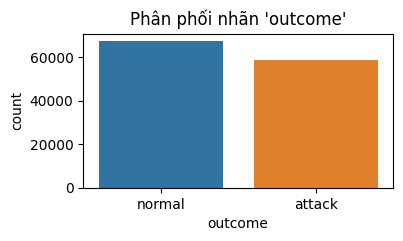

In [11]:
# Kiểm tra lại sự phân bố các nhãn trong cột 'outcome'
outcome_counts = data_train['outcome'].value_counts()
print(outcome_counts)
# Biểu đồ phân phối nhãn outcome
plt.figure(figsize=(4, 2))
sns.countplot(x=data_train['outcome'])
plt.title("Phân phối nhãn 'outcome'")
plt.show()

In [12]:
# Hàm vẽ nhiều biểu đồ tròn (pie chart) cùng lúc cho các cột phân loại
def pie_plot(df, cols_list, rows, cols):
    # Tạo figure gồm nhiều biểu đồ con (subplots)
    fig, axes = plt.subplots(rows, cols)

    # Duyệt qua từng cột và trục con tương ứng
    for ax, col in zip(axes.ravel(), cols_list):
        # Vẽ biểu đồ tròn cho phân bố giá trị trong cột col
        df[col].value_counts().plot(ax=ax, kind='pie', figsize=(15, 15), fontsize=10, autopct='%1.0f%%')
        # Đặt tiêu đề cho mỗi biểu đồ con
        ax.set_title(str(col), fontsize = 12)

    # Hiển thị toàn bộ biểu đồ
    plt.show()

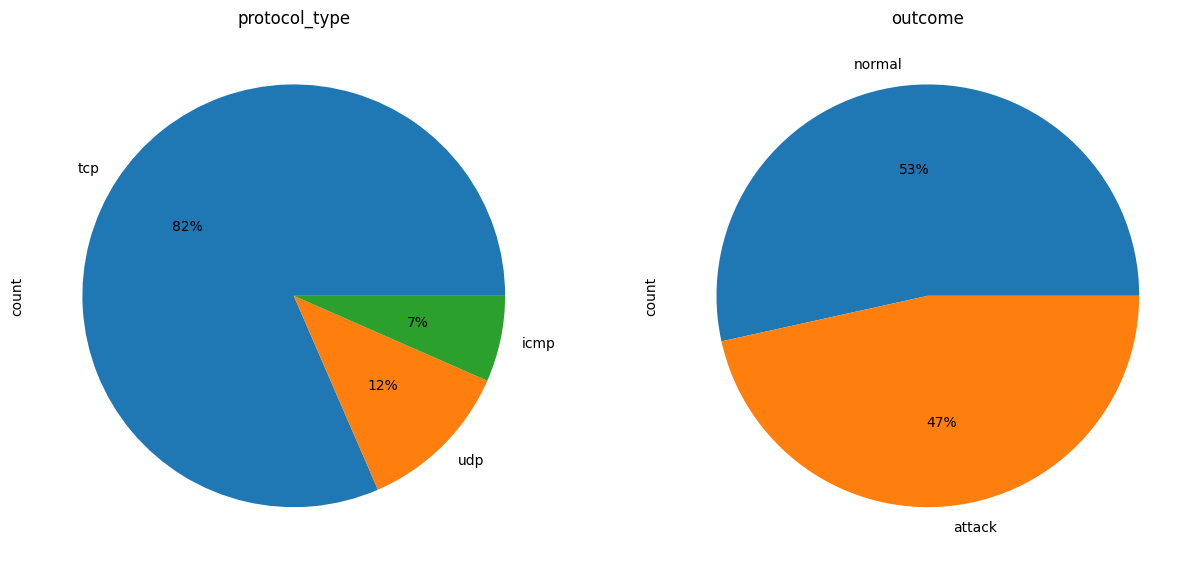

In [13]:
# Vẽ 2 biểu đồ tròn cho 2 cột
pie_plot(data_train, ['protocol_type', 'outcome'], 1, 2)

## Preprocessing the data

In [14]:
# Chuẩn hóa dữ liệu số (numeric) bằng kỹ thuật Robust Scaling, giúp giảm ảnh hưởng của các giá trị ngoại lệ.
# - df_num: DataFrame chỉ chứa các cột số cần chuẩn hóa
# - cols: danh sách tên cột (phải khớp với df_num.columns)
def Scaling(df_num, cols):
    std_scaler = RobustScaler()
    std_scaler_temp = std_scaler.fit_transform(df_num)
    # Tạo DataFrame mới từ dữ liệu đã chuẩn hóa
    std_df = pd.DataFrame(std_scaler_temp, columns =cols)
    return std_df

In [15]:
# Hàm tiền xử lý dữ liệu
# Danh sách các cột phân loại (categorical) và nhãn (outcome) sẽ không chuẩn hóa mà xử lý riêng
cat_cols = ['is_host_login','protocol_type','service','flag','land', 'logged_in','is_guest_login', 'level', 'outcome']
def preprocess(dataframe):
    # 1. Tách các cột số ra khỏi dữ liệu gốc
    df_num = dataframe.drop(cat_cols, axis=1)
    num_cols = df_num.columns

    # 2. Chuẩn hóa các cột số bằng RobustScaler
    scaled_df = Scaling(df_num, num_cols)
    
    # 3. Xóa các cột số chưa chuẩn hóa khỏi dataframe gốc
    dataframe.drop(labels=num_cols, axis="columns", inplace=True)

    # 4. Thêm lại các cột số sau khi đã chuẩn hóa
    dataframe[num_cols] = scaled_df[num_cols]

    # 5. Xử lý dữ liệu thiếu và trùng lặp
    dataframe.dropna(inplace=True)
    dataframe.drop_duplicates(inplace=True)

    # 6. Nhị phân hóa nhãn: 'normal' -> 0, tất cả còn lại -> 1
    dataframe.loc[dataframe['outcome'] == "normal", "outcome"] = 0
    
    dataframe.loc[dataframe['outcome'] != 0, "outcome"] = 1

    # 7. One-hot encode cho các cột phân loại (trừ 'outcome')
    # One-hot encoding cho 3 cột phân loại: protocol_type, service, flag
    # => để chuyển các biến phân loại (categorical) thành dạng số (numeric) mà mô hình máy học có thể hiểu đúng ý nghĩa của dữ liệu
    # Khi dùng PCA hoặc mạng nơ-ron, bạn nên có giữ One-Hot để dữ liệu tuyến tính hơn và không bị thứ tự ảo
    # Khi một cột có n giá trị phân loại khác nhau, pd.get_dummies() sẽ tạo ra n cột mới, dẫn tới số lượng cột tăng lên
    dataframe = pd.get_dummies(dataframe, columns = ['protocol_type', 'service', 'flag'])

    # 8. Trả về DataFrame đã tiền xử lý
    return dataframe

In [16]:
# Thực hiện tiền xử lý dữ liệu cho tập data_train
scaled_train = preprocess(data_train)
# Hiển thị số dòng và số cột của dữ liệu trong data_train sau khi one-hot encoding
print(scaled_train.shape)
scaled_train

(125964, 124)


,land,logged_in,is_host_login,is_guest_login,outcome,level,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_harvest,service_hostnames,service_http,service_http_2784,service_http_443,service_http_8001,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,0,0,0,0,20,0.0,1.619565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.085106,-0.3750,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,-0.606936,-0.155102,-0.357895,0.142857,2.833333,0.0,0.00,0.00,0.05,0.00,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0,0,15,0.0,0.369565,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.007092,-0.4375,0.0,0.0,0.0,0.0,-1.010989,2.500000,0.00,0.000000,-0.253061,-0.536842,8.285714,14.666667,0.0,0.00,0.00,0.00,0.00,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,1,19,0.0,-0.159420,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.773050,-0.1250,1.0,1.0,0.0,0.0,-1.043956,1.166667,0.00,0.000000,-0.151020,-0.431579,0.428571,0.000000,0.0,1.00,1.00,0.00,0.00,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,0,1,0,0,0,21,0.0,0.681159,15.800388,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [17]:
# Tách đặc trưng và nhãn
x = scaled_train.drop(['outcome', 'level'] , axis = 1).values # Dữ liệu đầu vào (features)
y = scaled_train['outcome'].values                            # Nhãn nhị phân (normal = 0, attack = 1)
y_reg = scaled_train['level'].values                          # Nhãn hồi quy (level 0–21)

# Giảm chiều với PCA
pca = PCA(n_components=20)    # Khởi tạo PCA giữ lại 20 thành phần chính
pca = pca.fit(x)              # Huấn luyện PCA trên toàn bộ x
x_reduced = pca.transform(x)  # Biến đổi dữ liệu sang không gian mới với 20 chiều
print("Number of original features is {} and of reduced features is {}".format(x.shape[1], x_reduced.shape[1]))

y = y.astype('int') # Chuyển nhãn y về kiểu int

# Chia tập train/test
# Cho phân loại nhị phân (dữ liệu gốc)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
# Cho phân loại nhị phân (sau khi PCA)
x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced = train_test_split(x_reduced, y, test_size=0.2, random_state=42)
# Cho bài toán hồi quy (predict 'level')
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x, y_reg, test_size=0.2, random_state=42)

# Mục đích các tập dữ liệu:
# - x_train, y_train: huấn luyện phân loại nhị phân
# - x_train_reduced: huấn luyện với dữ liệu đã giảm chiều (nhanh hơn, tránh overfitting)
# - x_train_reg, y_train_reg: dùng cho bài toán hồi quy (dự đoán level)

Number of original features is 122 and of reduced features is 20


## ***Evaluate ML Models Function***

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

# Hàm đánh giá mô hình phân loại nhị phân, gồm tính toán các chỉ số hiệu suất và
# trực quan hóa ma trận nhầm lẫn (confusion matrix) cho cả tập huấn luyện và kiểm thử
# Dữ liệu đầu vào:
# - model: mô hình ML đã được huấn luyện (fit)
# - name: tên mô hình (dùng trong tiêu đề)
# - X_train, X_test, y_train, y_test: tập dữ liệu và nhãn
# Kết quả đầu ra:
# - Precision, Recall, F1-score → phản ánh chất lượng mô hình (đặc biệt quan trọng với dữ liệu mất cân bằng).
# - Confusion matrix → giúp phân tích cụ thể số lượng dự đoán đúng/sai.
def evaluate_classification(model, name, X_train, X_test, y_train, y_test):
    # Predictions
    train_pred = model.predict(X_train)    
    test_pred = model.predict(X_test)
        
    # Compute confusion matrix for both train and test sets
    train_confusion_matrix = metrics.confusion_matrix(y_train, train_pred)
    test_confusion_matrix = metrics.confusion_matrix(y_test, test_pred)
    
    # Calculate metrics
    train_accuracy = metrics.accuracy_score(y_train, train_pred)
    train_precision = metrics.precision_score(y_train, train_pred)
    train_recall = metrics.recall_score(y_train, train_pred)
    train_f1 = metrics.f1_score(y_train, train_pred)    

    test_accuracy = metrics.accuracy_score(y_test, test_pred)
    test_precision = metrics.precision_score(y_test, test_pred)
    test_recall = metrics.recall_score(y_test, test_pred)
    test_f1 = metrics.f1_score(y_test, test_pred)    

    # Initialize AUC scores
    train_auc = test_auc = None

    # Check if model supports probability prediction
    supports_proba = hasattr(model, "predict_proba")
    if supports_proba:
        train_probs = model.predict_proba(X_train)[:, 1]
        test_probs = model.predict_proba(X_test)[:, 1]
        train_auc = roc_auc_score(y_train, train_probs)
        test_auc = roc_auc_score(y_test, test_probs)
    
    # Print metrics
    print(f"Training Metrics for {name}:")
    print(f"Accuracy: {train_accuracy*100:.2f}%, Precision: {train_precision*100:.2f}%, Recall: {train_recall*100:.2f}%, F1 Score: {train_f1*100:.2f}%" +
          (f", AUC: {train_auc*100:.2f}%" if train_auc is not None else ""))
    print(f"Testing Metrics for {name}:")
    print(f"Accuracy: {test_accuracy*100:.2f}%, Precision: {test_precision*100:.2f}%, Recall: {test_recall*100:.2f}%, F1 Score: {test_f1*100:.2f}%" +
          (f", AUC: {test_auc*100:.2f}%" if test_auc is not None else ""))

    # Plot confusion matrix
    plt.figure(figsize=(10, 10))

    plt.subplot(2, 2, 1)
    sns.heatmap(train_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Training Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.subplot(2, 2, 2)
    sns.heatmap(test_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Testing Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # ROC plots
    if supports_proba:
        fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
        fpr_test, tpr_test, _ = roc_curve(y_test, test_probs)

        plt.subplot(2, 2, 3)
        plt.plot(fpr_train, tpr_train, label=f"AUC = {train_auc:.4f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve (Train) for {name}")
        plt.legend(loc="lower right")
        plt.grid(True)

        plt.subplot(2, 2, 4)
        plt.plot(fpr_test, tpr_test, label=f"AUC = {test_auc:.4f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve (Test) for {name}")
        plt.legend(loc="lower right")
        plt.grid(True)
    
    plt.tight_layout()
    
    plt.show()

    return test_accuracy, test_precision, test_recall, test_f1, test_auc


## ***Models Training + evaluation + Confision Matrix***

### Logistic Regression

Training Metrics for Logistic Regression:
Accuracy: 89.11%, Precision: 88.72%, Recall: 87.77%, F1 Score: 88.24%, AUC: 90.90%
Testing Metrics for Logistic Regression:
Accuracy: 88.73%, Precision: 88.31%, Recall: 87.33%, F1 Score: 87.82%, AUC: 90.71%


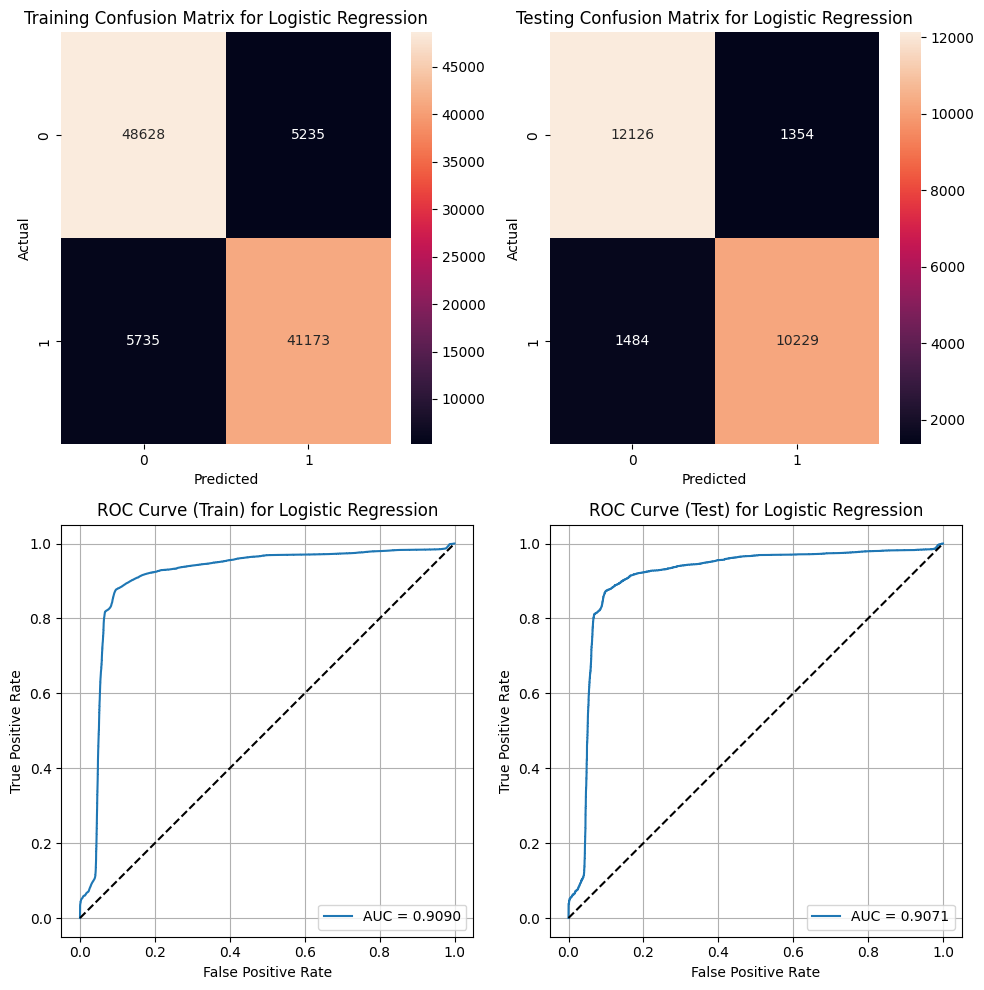

In [19]:
# Huấn luyện mô hình Logistic Regression trên x_train, y_train
# và đánh giá hiệu quả của mô hình dùng tập x_test, y_test
lr = LogisticRegression().fit(x_train, y_train)
lr_test_accuracy, lr_test_precision, lr_test_recall, lr_test_f1, lr_test_auc = evaluate_classification(lr, "Logistic Regression", x_train, x_test, y_train, y_test)

### Explainable AI for Logistic Regression

In [20]:
!pip install shap -q
# Hãy viết code giải thích 1 mẫu cụ thể dùng waterfall plot, force plot và decision plot trên tập dữ liệu x_train_reduced của model Logistic Regression. Chỉ giải thích trên 10 features có SHAP value cao nhất.

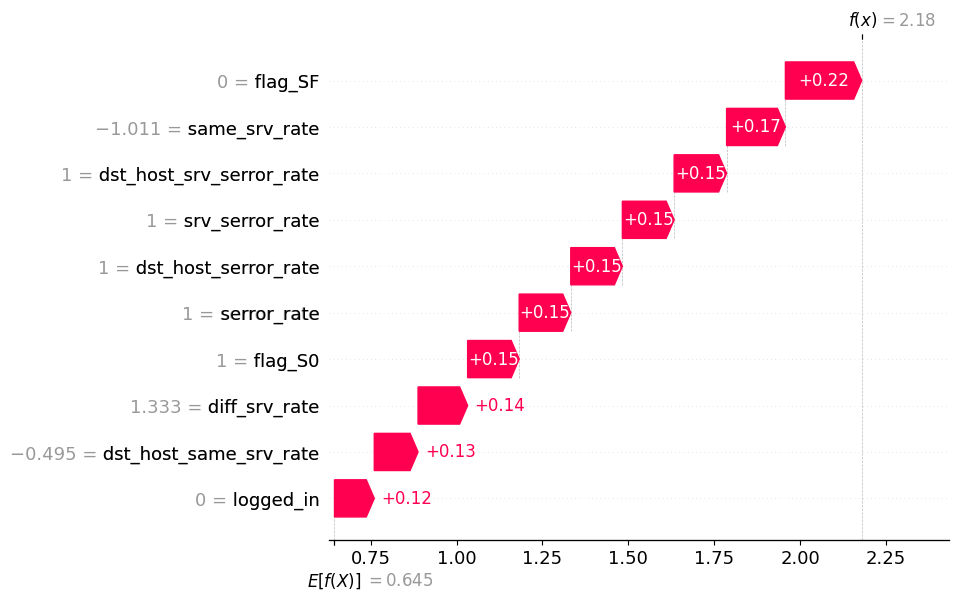

In [21]:
import shap
import pandas as pd
import numpy as np

# Tạo DataFrame từ x_train gốc
feature_names = scaled_train.drop(['outcome', 'level'], axis=1).columns
X_df = pd.DataFrame(x_train, columns=feature_names).astype(np.float64)

# Dùng LinearExplainer cho Logistic Regression
explainer = shap.LinearExplainer(lr, X_df, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_df)  # ndarray [n_samples, n_features]

# Chọn sample cần giải thích
sample_index = 0
sample_shap_values = shap_values[sample_index]
sample_data = X_df.iloc[sample_index]

# ✅ Lấy 10 đặc trưng có SHAP value lớn nhất về độ tuyệt đối
top_indices = np.argsort(np.abs(sample_shap_values))[-10:][::-1]
top_feature_names = feature_names[top_indices]
top_shap_values = sample_shap_values[top_indices]
top_feature_values = sample_data.values[top_indices]

# ✅ Waterfall plot cho top 10 đặc trưng
shap.plots.waterfall(
    shap.Explanation(
        values=top_shap_values,
        base_values=explainer.expected_value,
        data=top_feature_values,
        feature_names=top_feature_names
    )
)

# ✅ Force plot cho top 10 (chạy trong Jupyter)
shap.initjs()
shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=top_shap_values,
    features=top_feature_values,
    feature_names=top_feature_names
)

### Gaussian Naive Bayes

Training Metrics for GaussianNB:
Accuracy: 92.00%, Precision: 92.43%, Recall: 90.20%, F1 Score: 91.30%, AUC: 94.77%
Testing Metrics for GaussianNB:
Accuracy: 91.44%, Precision: 91.96%, Recall: 89.40%, F1 Score: 90.66%, AUC: 94.33%


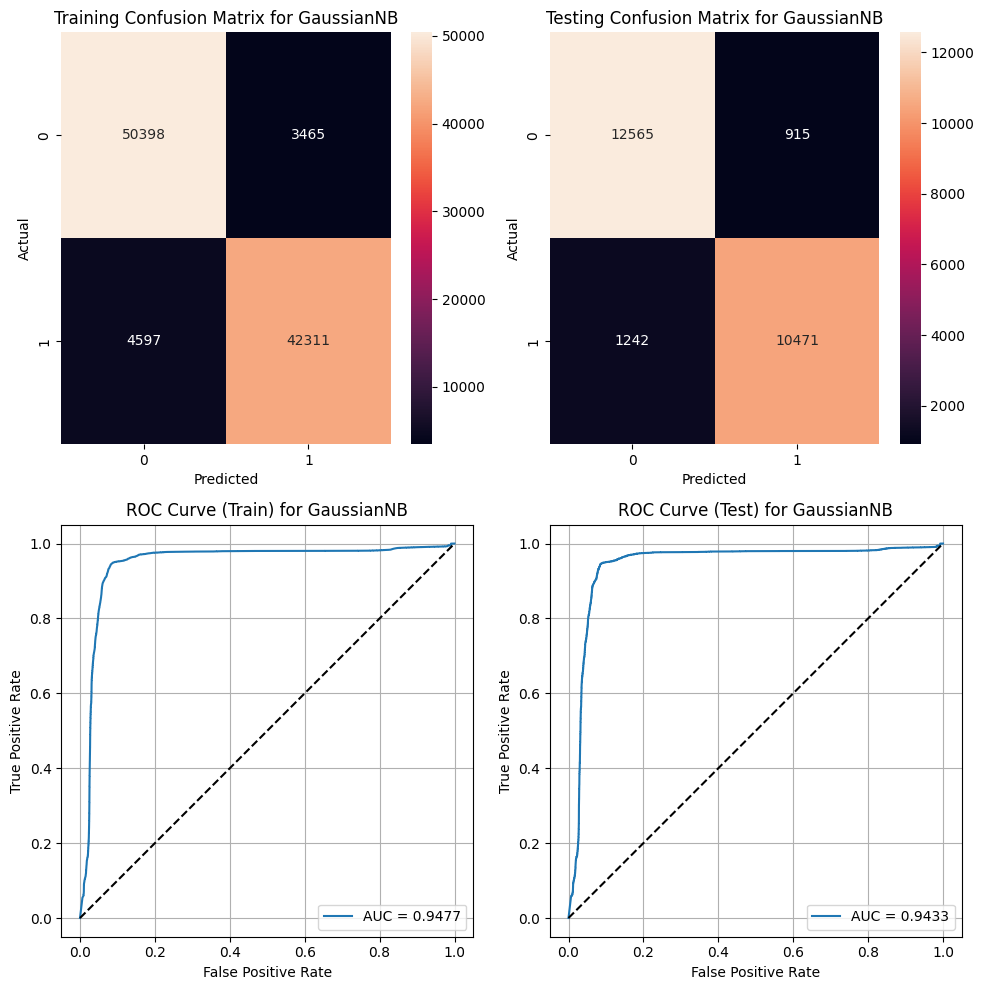

In [22]:
# Huấn luyện mô hình Gaussian Naive Bayes trên tập x_train, y_train
# và đánh giá hiệu quả của mô hình dùng tập x_test, y_test
gnb = GaussianNB().fit(x_train, y_train)
gnb_test_accuracy, gnb_test_precision, gnb_test_recall, gnb_test_f1, gnb_test_auc = evaluate_classification(gnb, "GaussianNB", x_train, x_test, y_train, y_test)

### SVM

Training Metrics for Linear SVC(LBasedImpl):
Accuracy: 97.04%, Precision: 96.74%, Recall: 96.90%, F1 Score: 96.82%
Testing Metrics for Linear SVC(LBasedImpl):
Accuracy: 96.92%, Precision: 96.70%, Recall: 96.68%, F1 Score: 96.69%


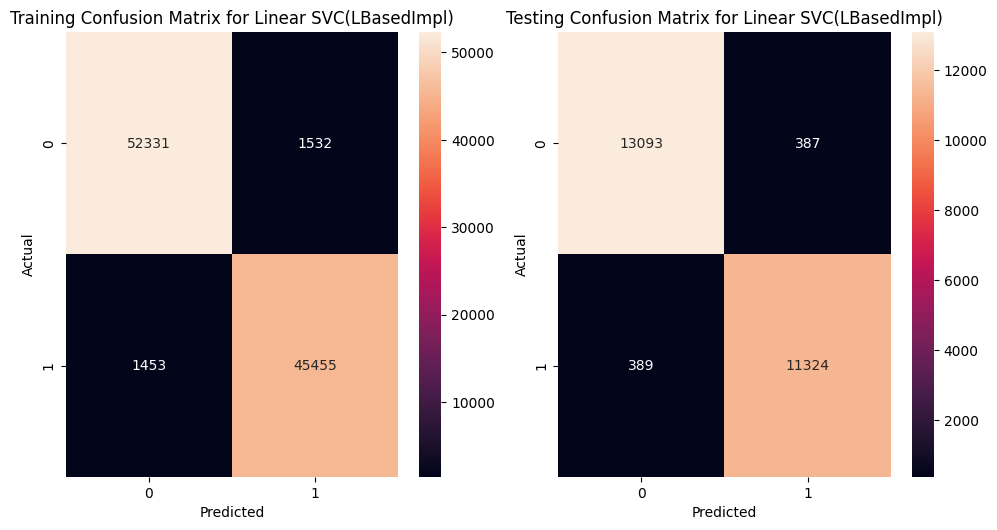

In [23]:
# Huấn luyện Support Vector Machine (Linear SVC) trên tập x_train, y_train
# và đánh giá hiệu quả của mô hình dùng tập x_test, y_test
lin_svc = svm.LinearSVC().fit(x_train, y_train)
lin_svc_test_accuracy, lin_svc_test_precision, lin_svc_test_recall, lin_svc_test_f1, lin_svc_test_auc = evaluate_classification(lin_svc, "Linear SVC(LBasedImpl)", x_train, x_test, y_train, y_test)

### Decison Tree

Training Metrics for DecisionTreeClassifier:
Accuracy: 100.00%, Precision: 100.00%, Recall: 99.99%, F1 Score: 100.00%, AUC: 100.00%
Testing Metrics for DecisionTreeClassifier:
Accuracy: 99.58%, Precision: 99.51%, Recall: 99.60%, F1 Score: 99.55%, AUC: 99.58%


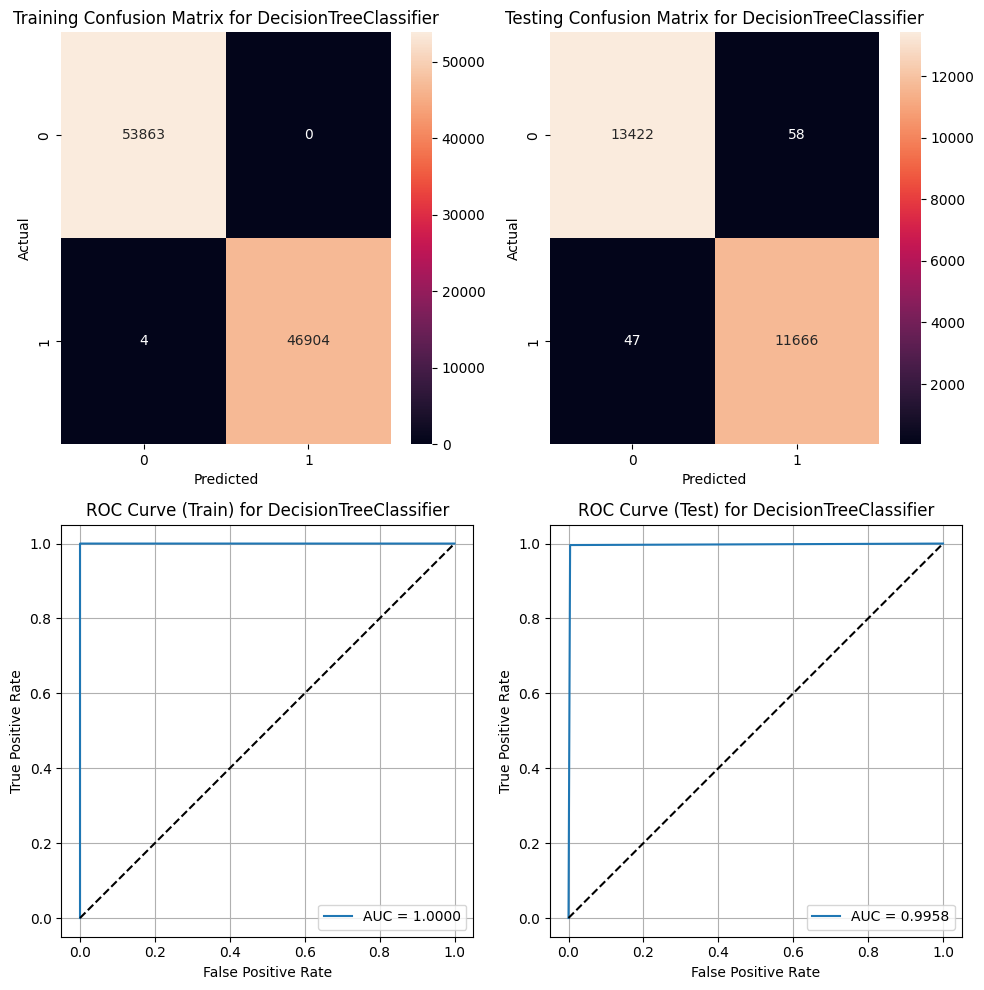

In [24]:
# Huấn luyện hai mô hình cây quyết định
#dt = DecisionTreeClassifier(max_depth=3).fit(x_train, y_train)  # Cây nông (depth = 3)
tdt = DecisionTreeClassifier().fit(x_train_reduced, y_train_reduced)            # Cây mặc định (không giới hạn độ sâu)
# và đánh giá mô hình không giới hạn độ sâu
tdt_test_accuracy, tdt_test_precision, tdt_test_recall, tdt_test_f1, tdt_test_auc = evaluate_classification(tdt, "DecisionTreeClassifier", x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced)

### features Importance

In [25]:
# Hàm trực quan hóa độ quan trọng của đặc trưng (feature importance) từ mô hình Decision Tree
def f_importances(coef, names, top=-1):
    imp = coef
    imp, names = zip(*sorted(list(zip(imp, names)))) # Sắp xếp theo importance tăng dần

    # Show all features
    if top == -1:       # Nếu không chỉ định số lượng top đặc trưng, lấy hết
        top = len(names)

    # Vẽ biểu đồ thanh ngang cho top đặc trưng quan trọng nhất
    plt.figure(figsize=(10,10))
    plt.barh(range(top), imp[::-1][0:top], align='center')
    plt.yticks(range(top), names[::-1][0:top])
    plt.title('feature importances for Decision Tree')
    plt.show()

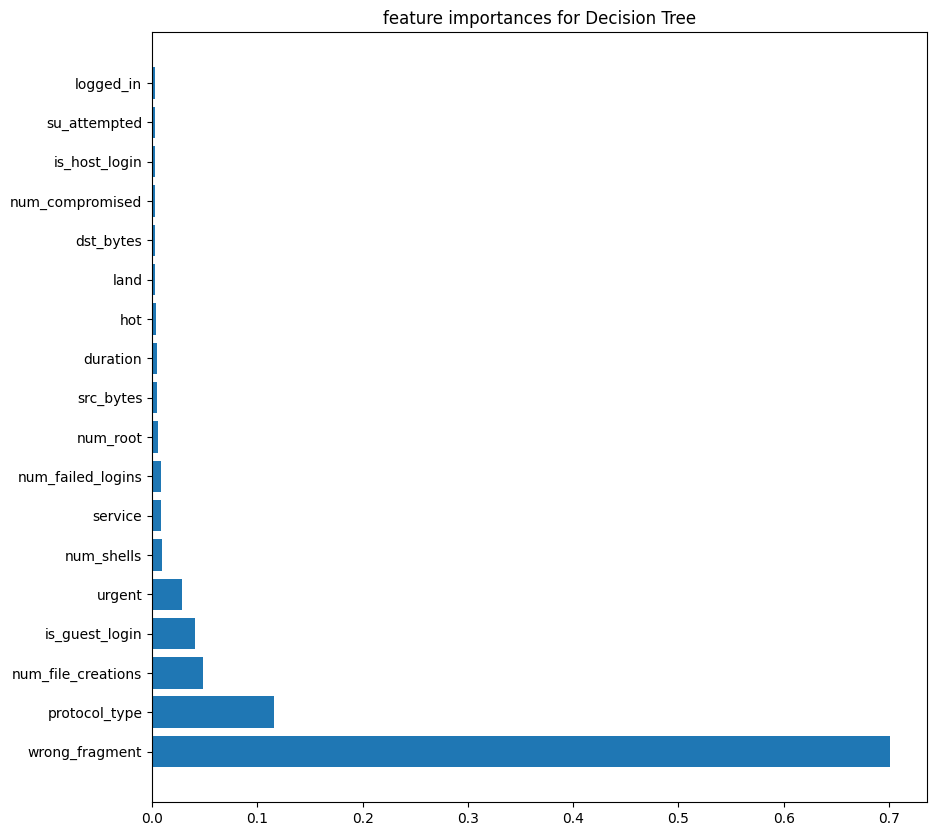

In [26]:
# Trực quan hóa độ quan trọng đặc trưng của mô hình Decision Tree
features_names = data_train.drop(['outcome', 'level'] , axis = 1)
f_importances(abs(tdt.feature_importances_), features_names, top=18)

### Random Forest

Training Metrics for RandomForestClassifier:
Accuracy: 100.00%, Precision: 100.00%, Recall: 99.99%, F1 Score: 100.00%, AUC: 100.00%
Testing Metrics for RandomForestClassifier:
Accuracy: 99.83%, Precision: 99.87%, Recall: 99.75%, F1 Score: 99.81%, AUC: 100.00%


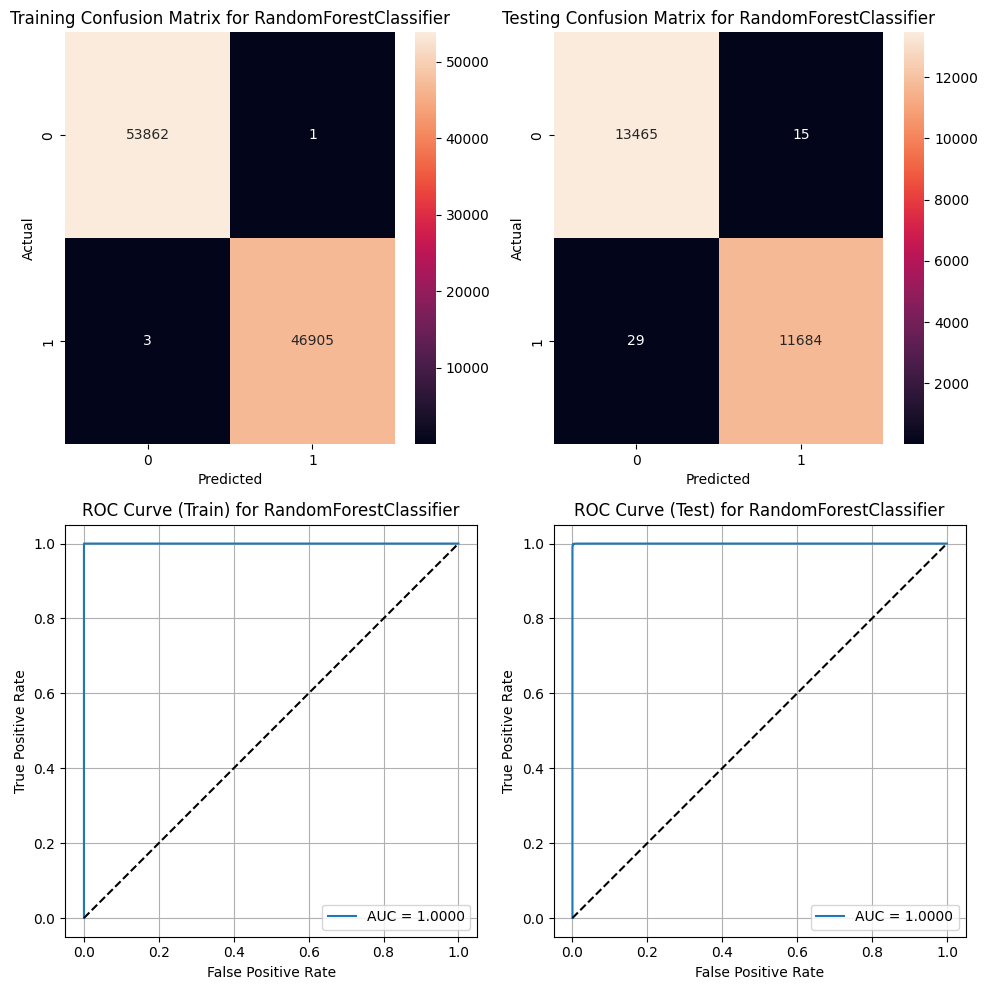

In [27]:
# Huấn luyện mô hình Random Forest (tập hợp nhiều cây quyết định) trên tập x_train, y_train
# và đánh giá hiệu quả của mô hình dùng tập x_test, y_test
rf = RandomForestClassifier().fit(x_train_reduced, y_train_reduced)
rf_test_accuracy, rf_test_precision, rf_test_recall, rf_test_f1, rf_test_auc = evaluate_classification(rf, "RandomForestClassifier", x_train_reduced, x_test_reduced, y_train_reduced, y_test_reduced)

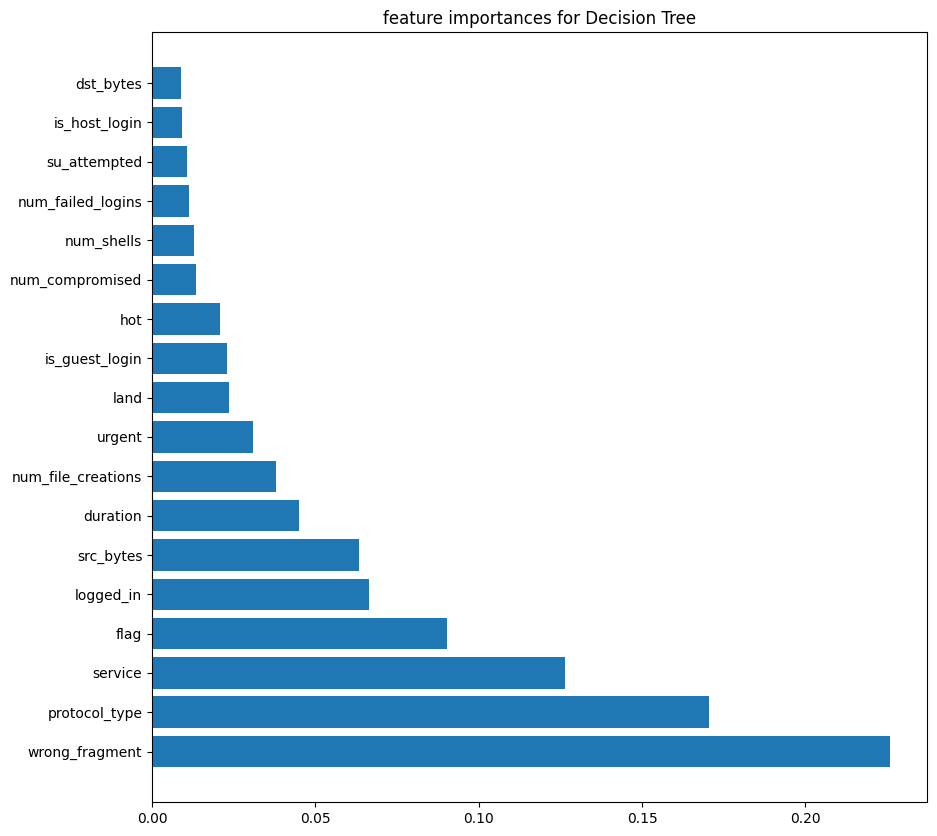

In [28]:
# Trực quan hóa độ quan trọng đặc trưng của mô hình Random Forest
f_importances(abs(rf.feature_importances_), features_names, top=18)

## ***Build Neural Network Model***

In [49]:
# Xây dựng một mạng neural đơn giản dùng Keras cho bài toán phân loại nhị phân
model = Sequential()
model.add(Input(shape=(x_train_reduced.shape[1],)))
model.add(Dense(32, activation='relu')) # init value = 64, optimized value = 32
model.add(Dense(16, activation='relu')) # init value = 64, optimized value = 16
# Lớp đầu ra với 1 neuron, dùng hàm sigmoid phù hợp với phân loại nhị phân
model.add(Dense(1, activation='sigmoid'))  # Use 'softmax' for multi-class classification

## ***Standardize features***

In [41]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_reduced)
x_test = scaler.transform(x_test_reduced)

## ***CNN Model Training***

In [50]:
# Mô hình này là MLP (Multi-Layer Perceptron)
# EarlyStopping giúp dừng huấn luyện sớm nếu mô hình không cải thiện
#   patience=5: Nếu val_loss không giảm sau 5 epochs, mô hình sẽ tự động dừng để tránh overfitting.
#   restore_best_weights=True: Khôi phục trọng số tốt nhất thay vì lấy trọng số ở epoch cuối.
from tensorflow.keras.callbacks import EarlyStopping
# Huấn luyện mô hình học sâu CNN
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
# validation_split=0.2: 20% dữ liệu huấn luyện dùng để đánh giá validation (không cần tập valid riêng)
# history: là đối tượng lưu lịch sử huấn luyện (loss, accuracy theo từng epoch), có thể dùng để trực quan hóa
history = model.fit(x_train, y_train, validation_split=0.2, epochs=20, batch_size=16,
  callbacks = [
        EarlyStopping(patience = 5, restore_best_weights = True)
  ]
)

Epoch 1/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9461 - loss: 0.1394 - val_accuracy: 0.9893 - val_loss: 0.0356
Epoch 2/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9905 - loss: 0.0292 - val_accuracy: 0.9905 - val_loss: 0.0293
Epoch 3/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9915 - loss: 0.0249 - val_accuracy: 0.9921 - val_loss: 0.0252
Epoch 4/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9921 - loss: 0.0227 - val_accuracy: 0.9900 - val_loss: 0.0284
Epoch 5/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9928 - loss: 0.0205 - val_accuracy: 0.9914 - val_loss: 0.0240
Epoch 6/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9936 - loss: 0.0195 - val_accuracy: 0.9932 - val_loss: 0.0223
Epoch 7/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9924 - val_loss: 0.0229
Epoch 8/20
5039/5039 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9939 - loss: 0.0176 -

## ***Model Evaluation***

3150/3150 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Training Metrics for CNN:
Accuracy: 99.47%, Precision: 99.69%, Recall: 99.16%, F1 Score: 99.43%, AUC: 99.45%
Testing Metrics for CNN:
Accuracy: 99.41%, Precision: 99.72%, Recall: 99.02%, F1 Score: 99.37%, AUC: 99.39%


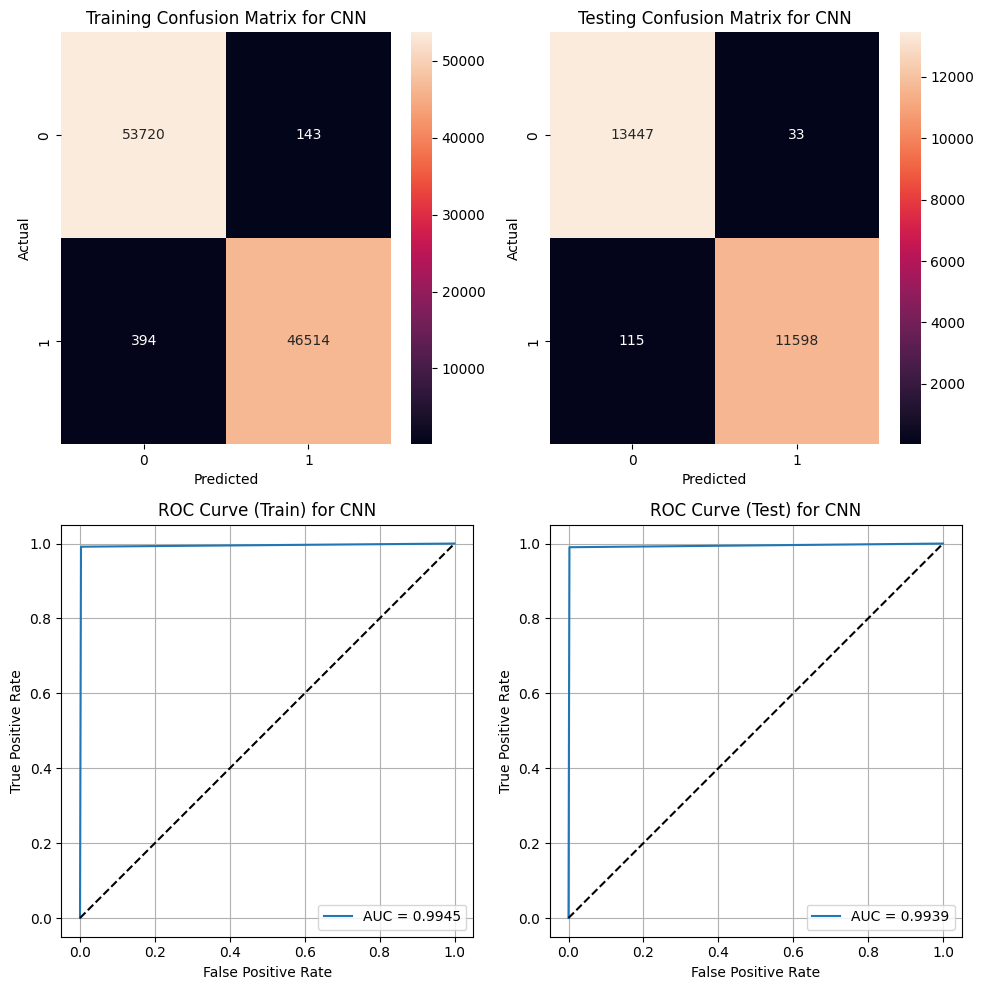

In [51]:
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Hàm đánh giá mô hình mạng nơ-ron (neural network)
def evaluate_classificationCNN(model, name, X_train, X_test, y_train, y_test):
    # Convert probabilities to binary labels
    train_pred = (model.predict(X_train) > 0.5).astype("int32")
    test_pred = (model.predict(X_test) > 0.5).astype("int32")

    # Calculate metrics for training data
    train_accuracy = metrics.accuracy_score(y_train, train_pred)
    train_precision = metrics.precision_score(y_train, train_pred)
    train_recall = metrics.recall_score(y_train, train_pred)
    train_f1 = metrics.f1_score(y_train, train_pred)

    # Calculate metrics for testing data
    test_accuracy = metrics.accuracy_score(y_test, test_pred)
    test_precision = metrics.precision_score(y_test, test_pred)
    test_recall = metrics.recall_score(y_test, test_pred)
    test_f1 = metrics.f1_score(y_test, test_pred)    

    # Confusion matrices
    train_confusion_matrix = metrics.confusion_matrix(y_train, train_pred)
    test_confusion_matrix = metrics.confusion_matrix(y_test, test_pred)

    # AUC
    train_auc = roc_auc_score(y_train, train_pred)
    test_auc = roc_auc_score(y_test, test_pred)
    
    # Print metrics
    print(f"Training Metrics for {name}:")
    print(f"Accuracy: {train_accuracy*100:.2f}%, Precision: {train_precision*100:.2f}%, Recall: {train_recall*100:.2f}%, F1 Score: {train_f1*100:.2f}%" +
          (f", AUC: {train_auc*100:.2f}%" if train_auc is not None else ""))
    print(f"Testing Metrics for {name}:")
    print(f"Accuracy: {test_accuracy*100:.2f}%, Precision: {test_precision*100:.2f}%, Recall: {test_recall*100:.2f}%, F1 Score: {test_f1*100:.2f}%" +
          (f", AUC: {test_auc*100:.2f}%" if test_auc is not None else ""))

    # Plot confusion matrix
    plt.figure(figsize=(10, 10))

    plt.subplot(2, 2, 1)
    sns.heatmap(train_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Training Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.subplot(2, 2, 2)
    sns.heatmap(test_confusion_matrix, annot=True, fmt='g')
    plt.title(f'Testing Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # ROC plots    
    fpr_train, tpr_train, _ = roc_curve(y_train, train_pred)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_pred)
    
    plt.subplot(2, 2, 3)
    plt.plot(fpr_train, tpr_train, label=f"AUC = {train_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Train) for {name}")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(fpr_test, tpr_test, label=f"AUC = {test_auc:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Test) for {name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    
    plt.tight_layout()
    
    plt.show()

    return test_accuracy, test_precision, test_recall, test_f1, test_auc

# Đánh giá mô hình CNN đã được huấn luyện
cnn_test_accuracy, cnn_test_precision, cnn_test_recall, cnn_test_f1, cnn_test_auc = evaluate_classificationCNN(model, "CNN", x_train, x_test, y_train, y_test)

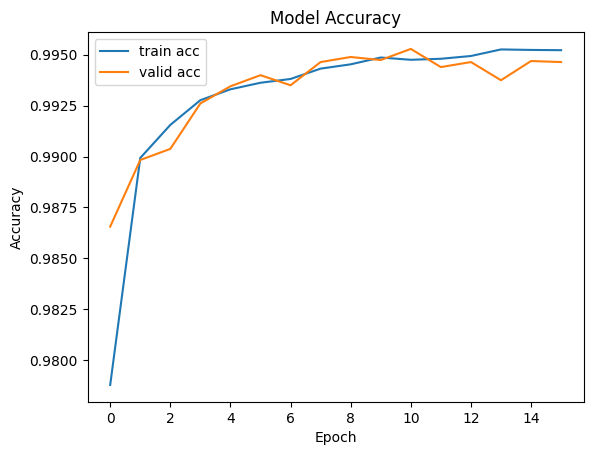

In [44]:
# Vẽ biểu đồ Accuracy (độ chính xác) của mô hình trong quá trình huấn luyện (theo epoch)
plt.plot(history.history['accuracy']) # Vẽ độ chính xác trên tập huấn luyện (train accuracy)
plt.plot(history.history['val_accuracy']) # Vẽ độ chính xác trên tập validation (validation accuracy)

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train acc', 'valid acc'], loc='upper left')

In [52]:
model_accuracy = pd.DataFrame({
    'Model': ['Linear Regression', 'Gaussian Naive Bayes', 'Support Vector Machine', 'Decision Tree', 'Random Forest', 'Convolutional Neural Network'],
    'Test Accuracy': [lr_test_accuracy, gnb_test_accuracy, lin_svc_test_accuracy, tdt_test_accuracy, rf_test_accuracy, cnn_test_accuracy],
    'Test Precision': [lr_test_precision, gnb_test_precision, lin_svc_test_precision, tdt_test_precision, rf_test_precision, cnn_test_precision],
    'Test Recall': [lr_test_recall, gnb_test_recall, lin_svc_test_recall, tdt_test_recall, rf_test_recall, cnn_test_recall],
    'Test F1-Score': [lr_test_f1, gnb_test_f1, lin_svc_test_f1, tdt_test_f1, rf_test_f1, cnn_test_f1],
    'Test AUC': [lr_test_auc, gnb_test_auc, lin_svc_test_auc, tdt_test_auc, rf_test_auc, cnn_test_auc]
})
model_accuracy.sort_values(by='Test F1-Score', ascending=False)

,Model,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test AUC
4,Random Forest,0.998253,0.998718,0.997524,0.998121,0.999983
3,Decision Tree,0.995832,0.995053,0.995987,0.995520,0.995842
5,Convolutional Neural Network,0.994125,0.997163,0.990182,0.993660,0.993867
2,Support Vector Machine,0.969198,0.966954,0.966789,0.966872,NaN
1,Gaussian Naive Bayes,0.914381,0.919638,0.893964,0.906619,0.943316
0,Linear Regression,0.887350,0.883105,0.873303,0.878177,0.907085


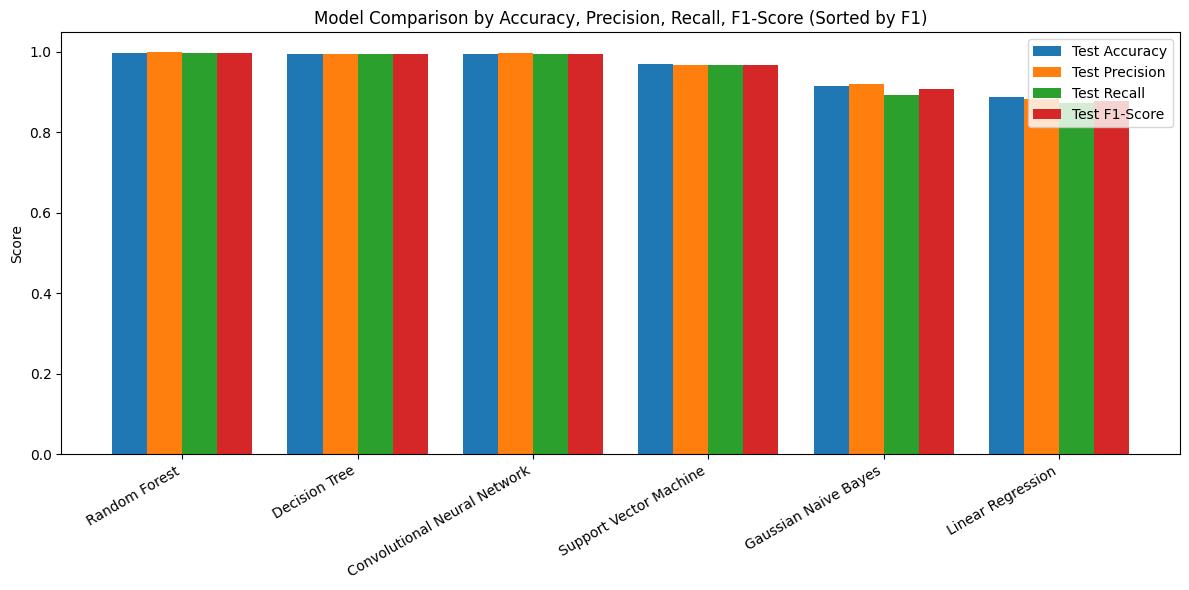

In [37]:
# Sắp xếp model_accuracy theo F1-Score giảm dần
sorted_df = model_accuracy.sort_values(by='Test F1-Score', ascending=False).reset_index(drop=True)
# Chuyển từ wide format sang long format
df_melted = sorted_df.melt(id_vars='Model', 
                           value_vars=['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score'],
                           var_name='Metric', 
                           value_name='Score')
plt.figure(figsize=(12, 6))
# Lấy danh sách model và metric
models = sorted_df['Model'].tolist()
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score']
bar_width = 0.2
x = range(len(models))
# Vẽ từng nhóm cột
for i, metric in enumerate(metrics):
    metric_scores = df_melted[df_melted['Metric'] == metric]['Score']
    plt.bar([pos + i * bar_width for pos in x], metric_scores, width=bar_width, label=metric)
# Cấu hình trục x
plt.xticks([pos + 1.5 * bar_width for pos in x], models, rotation=30, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison by Accuracy, Precision, Recall, F1-Score (Sorted by F1)')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# importing lime
import lime
from lime import lime_tabular

In [34]:
f_names = [f'feature_{i}' for i in range(x_train_reduced.shape[1])]

# creating an instance of the lime tabular explainer
lime_explainer = lime_tabular.LimeTabularExplainer(training_data=x_train_reduced, feature_names=f_names, 
            class_names=['1', '2'], mode='classification')

In [35]:
# obtaining the explanation
explanation = lime_explainer.explain_instance(data_row=x_test_reduced[1], predict_fn=lr.predict_proba, top_labels=4, num_features=len(f_names))

# printing out the explanation
explanation.show_in_notebook()

## ***Optimisation Using RandomizedSearchCV***

In [47]:
!pip install scikeras==0.13.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 96.2 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.


In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

# Xây dựng mô hình Keras
def build_model(units1=64, units2=64, learning_rate=0.001, **kwargs):
    model = Sequential()
    model.add(Dense(units=units1, activation='relu', input_shape=(x_train_reduced.shape[1],)))
    model.add(Dense(units=units2, activation='relu'))
    model.add(Dense(1, activation='sigmoid')) # Use 'softmax' for multi-class classification
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Tạo wrapper để tích hợp với RandomizedSearchCV
# Wrap the model with KerasClassifier, include callbacks parameter
def keras_classifier_wrapper(model_fn, callbacks=None):
    return KerasClassifier(model=model_fn, verbose=0, callbacks=callbacks)

# Định nghĩa không gian siêu tham số
# Define the hyperparameter search space
param_grid2 = {
    'model__units1': [64, 128, 256],
    'model__units2': [32, 64, 128],
    'model__learning_rate': [0.01, 0.001, 0.0001],
    # Các tham số cho hàm fit không cần tiền tố
    'batch_size': [16, 32, 64],
    'epochs': [10, 20, 30]
}

param_grid = {
    'model__units1': [16, 32, 64, 128, 256],
    'model__units2': [16, 32, 64, 128, 256],
    'model__learning_rate': [0.01, 0.001, 0.0001],
    # Các tham số cho hàm fit không cần tiền tố
    'batch_size': [16, 32, 64],
    'epochs': [10, 20, 30]    
}

# Initialize TensorBoard callback
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir='./logs')

# Initialize model with TensorBoard callback
model = keras_classifier_wrapper(model_fn=build_model, callbacks=None)

# Chạy RandomizedSearchCV
# Use RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=3,
    cv=3,
    n_jobs=1,    
    verbose=0
)

# Huấn luyện trên GPU và chạy tìm kiếm
# Specify GPU for training and fit the model
#with tf.device('/GPU:0'):
random_search_results = random_search.fit(x_train_reduced, y_train_reduced)

# In kết quả tốt nhất: in điểm số cross-validation tốt nhất và bộ tham số tương ứng
# Print best score and parameters
print("Best: %f using %s" % (random_search_results.best_score_, random_search_results.best_params_))
# => Tự động tìm được mô hình Keras tốt nhất dựa trên tập train hiện tại

#Best: 0.967272 using {'model__units2': 16, 'model__units1': 32, 
#'model__learning_rate': 0.001, 'epochs': 5, 'batch_size': 16}

Best: 0.979042 using {'model__units2': 32, 'model__units1': 32, 'model__learning_rate': 0.0001, 'epochs': 10, 'batch_size': 16}
